# Two-Layer Energy Balance Model (EBM) — Variable Atmospheric Emissivity
### Atmosphere · Ocean (combined, full depth)

This is a variant of the two-layer EBM in `TwoLayerModel.ipynb`. Everything about the
model geometry, ocean heat capacity, and SAI mechanism is unchanged — the only physical
difference is **how CO₂ affects outgoing longwave radiation (OLR)**.

The original model linearizes OLR as $a + bT$ and adds a prescribed CO₂ forcing $F(t)$
on top. Here, instead, the atmosphere is treated as a grey body with an **effective
emissivity $\varepsilon$ that decreases as CO₂ rises** — a more physically motivated
representation of the greenhouse effect, in which added CO₂ makes the atmospheric column
more opaque to infrared radiation rather than simply shifting a linear intercept:

$$C_a\frac{dT_a}{dt} = S\bigl(1-\alpha(t)\bigr) - \varepsilon\bigl(\mathrm{CO_2}(t)\bigr)\,\sigma T_a^4 - \gamma_{ao}(T_a - T_o)$$
$$C_o\frac{dT_o}{dt} = \gamma_{ao}(T_a - T_o)$$
$$\varepsilon(\mathrm{CO_2}) = \varepsilon_0 - \frac{5.35\,\ln(\mathrm{CO_2}/\mathrm{CO_2}_0)}{\sigma T_0^4}$$

| Symbol | Meaning | Units |
|--------|---------|-------|
| $T_a,\,T_o$ | Atmosphere / ocean temperature | K |
| $C_a$ | Atmospheric-column heat capacity | W·yr/m²/°C |
| $C_o$ | Full-column ocean heat capacity | W·yr/m²/°C |
| $\gamma_{ao}$ | Atmosphere ↔ ocean heat exchange | W/m²/°C |
| $\sigma$ | Stefan–Boltzmann constant | W/m²/K⁴ |
| $\varepsilon(\mathrm{CO_2})$ | Effective atmospheric emissivity | dimensionless |
| $\mathrm{CO_2}(t)$ | Atmospheric CO₂ concentration | ppm |
| $S,\ \alpha(t)$ | Insolation, albedo (incl. SAI offset) | as in the single-layer model |

The logarithmic term $5.35\ln(\mathrm{CO_2}/\mathrm{CO_2}_0)$ is the standard Myhre et al.
(1998) CO₂ radiative-forcing formula. Rather than adding it to the flux directly, it is
folded into $\varepsilon$ so that CO₂ acts on the *radiative properties of the
atmosphere* — reducing $\varepsilon$, and hence OLR — instead of appearing as a bare
additive forcing term.

$\mathrm{CO_2}(t)$ is **real data**, not a synthetic curve:

- **1850–1978**: Meinshausen et al. (2017) / CMIP6 historical GHG concentrations
  (RCMIP "historical" series).
- **1979–2023**: NOAA GML observed global annual-mean CO₂ — actual measurements.
- **2024–2100**: an RCMIP/CMIP6 **SSP concentration pathway** (SSP1-2.6 / SSP2-4.5 /
  SSP5-8.5) for the chosen scenario, offset-anchored to the real 2023 value so each
  projection continues smoothly from observations instead of jumping to RCMIP's
  (decade-old, slightly higher) projected 2023 value.

See `data/co2_historical_1850_2023.csv` and `data/co2_ssp_scenarios_2024_2100.csv`
(sourced from the [RCMIP concentrations dataset](https://zenodo.org/records/4589756) and
[NOAA GML](https://gml.noaa.gov/ccgg/trends/gl_data.html)). CO₂ radiative forcing
$F(t) = 5.35\ln(\mathrm{CO_2}(t)/\mathrm{CO_2}_0)$ is now *derived* from this real record
rather than independently fit — earlier versions of this notebook back-calculated a
CO₂-equivalent concentration by inverting a synthetic multi-gas forcing curve; this
version runs on literal atmospheric CO₂ instead. The model horizon is **1850–2100**.

Because OLR now depends on $T_a^4$ instead of a linear $a+bT$, the Planck feedback is no
longer a free-tuned parameter ($b=2.09$ W/m²/K in the original model) but instead falls
out of $4\varepsilon_0\sigma T_0^3$ — a pure Planck response, with no implicit
water-vapor/ice-albedo feedback baked in. Expect a *stronger* net negative feedback (more
resistance to warming) than the original linear-OLR model.

In [16]:
%matplotlib inline
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

In [17]:
# == Physical constants =======================================================
S0     = 1361.0   # Solar constant [W/m2]
S      = S0 / 4   # Sphere-averaged mean insolation [W/m2]
SIGMA  = 5.670374419e-8   # Stefan-Boltzmann constant [W/m2/K4]

# == Pre-industrial baseline (1850) ===========================================
alpha0 = 0.30     # Planetary albedo
T0     = 288.15   # Surface temperature [K]  (~15 C)

# == CO2 -> emissivity: Myhre et al. (1998) logarithmic forcing =============
CO2_0 = 280.0     # pre-industrial CO2 concentration [ppm]
K_CO2 = 5.35      # log-CO2 forcing coefficient [W/m2]

# OLR = eps(CO2) * SIGMA * Ta^4 ; eps0 is set so that CO2=CO2_0 gives T_eq = T0 exactly.
OLR0 = S * (1 - alpha0)          # required pre-industrial OLR [W/m2]
EPS0 = OLR0 / (SIGMA * T0**4)    # pre-industrial effective atmospheric emissivity [-]

# == Layer heat capacities ====================================================
RHO_W      = 1025.0     # seawater density [kg/m3]
CP_W       = 3990.0     # seawater heat capacity [J/kg/K]
F_OCEAN    = 0.71       # ocean fraction of Earth's surface
CP_AIR     = 1004.0     # air heat capacity [J/kg/K]
P_SURF     = 1.01325e5  # surface pressure [Pa]
G_GRAV     = 9.81       # gravity [m/s2]
SEC_PER_YR = 3.1557e7

OCEAN_DEPTH = 3700.0    # combined ocean thickness [m]  (0–3700 m)

def ocean_layer_C(depth_m, f_ocean=F_OCEAN):
    """Heat capacity per m2 of Earth for an ocean layer [W.yr/m2/K]."""
    return RHO_W * CP_W * depth_m * f_ocean / SEC_PER_YR

C_ATMOS = CP_AIR * P_SURF / G_GRAV / SEC_PER_YR   # atmospheric column
C_OCEAN = ocean_layer_C(OCEAN_DEPTH)               # combined ocean layer

# == Atmosphere <-> ocean heat-exchange coefficient [W/m2/K] ==================
GAMMA_AO = 10.0   # atmosphere <-> ocean (air-sea coupling)

B_PLANCK = 4 * EPS0 * SIGMA * T0**3   # Planck feedback at T0, for comparison to the
                                       # tuned b=2.09 W/m2/K slope in TwoLayerModel.ipynb

print(f"Pre-industrial OLR = {OLR0:.3f} W/m2  ->  eps0 = {EPS0:.4f}")
print(f"Planck feedback at T0:  4*eps0*sigma*T0^3 = {B_PLANCK:.3f} W/m2/K  "
      f"(cf. tuned b = 2.09 W/m2/K in the linear-OLR model)")
print(f"Heat capacities [W.yr/m2/K]:  C_a = {C_ATMOS:.3f}   C_o = {C_OCEAN:.1f}")
print(f"Response timescales:  atmosphere ~ {C_ATMOS/(B_PLANCK+GAMMA_AO):.3f} yr   "
      f"ocean ~ {C_OCEAN/GAMMA_AO:.0f} yr")
print(f"Equilibrium check  ->  T_eq = {(OLR0/(EPS0*SIGMA))**0.25:.4f} K  (target: {T0} K)")

Pre-industrial OLR = 238.175 W/m2  ->  eps0 = 0.6093
Planck feedback at T0:  4*eps0*sigma*T0^3 = 3.306 W/m2/K  (cf. tuned b = 2.09 W/m2/K in the linear-OLR model)
Heat capacities [W.yr/m2/K]:  C_a = 0.329   C_o = 340.5
Response timescales:  atmosphere ~ 0.025 yr   ocean ~ 34 yr
Equilibrium check  ->  T_eq = 288.1500 K  (target: 288.15 K)


In [18]:
# Real CO2 data, replacing the earlier synthetic linear-ramp + quadratic-fit
# approximation:
#
#   1850-1978 : Meinshausen et al. (2017) / CMIP6 historical GHG
#               concentrations (RCMIP "historical" series).
#   1979-2023 : NOAA GML observed global annual-mean CO2 -- real
#               measurements, not a reconstruction.
#   2024-2100 : RCMIP/CMIP6 SSP concentration pathway for the chosen
#               scenario (SSP1-2.6 / SSP2-4.5 / SSP5-8.5), offset-anchored
#               to the actual 2023 observed value so each projection
#               continues smoothly from real data instead of jumping to
#               RCMIP's (decade-old, slightly higher) projected 2023 value.
#
# See data/co2_historical_1850_2023.csv and data/co2_ssp_scenarios_2024_2100.csv
# (built from https://zenodo.org/records/4589756 and
# https://gml.noaa.gov/ccgg/trends/gl_data.html).
DATA_DIR = None
for _candidate in [pathlib.Path("data"), pathlib.Path("../data")]:
    if (_candidate / "co2_historical_1850_2023.csv").exists():
        DATA_DIR = _candidate
        break
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find data/co2_historical_1850_2023.csv -- run this notebook "
        "from the 'code' directory it lives in (or alongside a sibling 'data' folder)."
    )

SSP_SCENARIOS = ['ssp126', 'ssp245', 'ssp585']


def _load_co2_data():
    hist = np.genfromtxt(DATA_DIR / "co2_historical_1850_2023.csv", delimiter=",", skip_header=1)
    ssp  = np.genfromtxt(DATA_DIR / "co2_ssp_scenarios_2024_2100.csv", delimiter=",", skip_header=1)
    hist_years, hist_ppm = hist[:, 0], hist[:, 1]
    ssp_years = ssp[:, 0]
    ssp_cols  = {'ssp126': ssp[:, 1], 'ssp245': ssp[:, 2], 'ssp585': ssp[:, 3]}

    years_by_scenario, ppm_by_scenario = {}, {}
    for name in SSP_SCENARIOS:
        years_by_scenario[name] = np.concatenate([hist_years, ssp_years])
        ppm_by_scenario[name]   = np.concatenate([hist_ppm, ssp_cols[name]])
    return years_by_scenario, ppm_by_scenario


_CO2_YEARS, _CO2_PPM = _load_co2_data()


def co2_ppm(t, scenario='ssp245'):
    """
    Atmospheric CO2 concentration [ppm] -- real historical record spliced
    with a real SSP concentration pathway (see module docstring above).
    'none' is a pre-industrial control: CO2 held at CO2_0 for all t.
    """
    if scenario == 'none':
        return CO2_0
    return np.interp(t, _CO2_YEARS[scenario], _CO2_PPM[scenario])


def co2_forcing(t, scenario='ssp245'):
    """
    CO2 radiative forcing relative to pre-industrial [W/m2], via the
    Myhre et al. (1998) logarithmic formula applied to the real CO2 record
    from co2_ppm() (rather than an independently-fit forcing curve).
    """
    if scenario == 'none':
        return 0.0
    return K_CO2 * np.log(co2_ppm(t, scenario=scenario) / CO2_0)


def emissivity(CO2):
    """
    Effective atmospheric emissivity: decreases (atmosphere becomes more
    IR-opaque) as CO2 rises above CO2_0. Vectorized over CO2.
    """
    return EPS0 - K_CO2 * np.log(CO2 / CO2_0) / (SIGMA * T0**4)


def sai_delta_alpha(t, d_alpha=0.0, start_year=2030, ramp_years=10, d_alpha_slope=0.0):
    """
    Albedo offset from stratospheric aerosol injection (SAI).

    Phase 1 – pre-deployment  [t < start_year]:              0
    Phase 2 – ramp-up         [start_year, start_year+ramp): linear 0 -> d_alpha
    Phase 3 – post-ramp       [t >= start_year+ramp):        d_alpha + d_alpha_slope*(t-ramp_end)
    """
    if d_alpha == 0.0 or t < start_year:
        return 0.0
    ramp_end = start_year + ramp_years
    if t < ramp_end:
        return d_alpha * (t - start_year) / ramp_years
    return d_alpha + d_alpha_slope * (t - ramp_end)


def net_toa_imbalance(t, Ta, d_alpha=0.0, scenario='ssp245',
                      sai_start=2030, sai_ramp=10, d_alpha_slope=0.0):
    """Net top-of-atmosphere radiative flux  S(1-alpha) - eps(CO2(t))*sigma*Ta^4   [W/m2]."""
    alpha = alpha0 + sai_delta_alpha(t, d_alpha=d_alpha, start_year=sai_start,
                                     ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope)
    eps = emissivity(co2_ppm(t, scenario=scenario))
    return S * (1 - alpha) - eps * SIGMA * Ta**4


def layer_derivs(t, y, C_a, C_o, gamma_ao,
                 d_alpha=0.0, scenario='ssp245', sai_start=2030, sai_ramp=10, d_alpha_slope=0.0):
    """
    Right-hand side of the two-layer system.  y = [T_a, T_o].

    Atmosphere sees the net TOA radiation -- whose OLR term now depends on the
    CO2-dependent emissivity eps(CO2(t)) rather than a linear a+bT+F(t) -- and
    exchanges heat with the ocean; the single ocean layer absorbs whatever the
    atmosphere passes down.
    """
    Ta, To = y
    R    = net_toa_imbalance(t, Ta, d_alpha, scenario, sai_start, sai_ramp, d_alpha_slope)
    f_ao = gamma_ao * (Ta - To)   # atmosphere -> ocean
    return [(R - f_ao) / C_a,
            (f_ao)     / C_o]


def run_ebm(C_a=C_ATMOS, C_o=C_OCEAN,
            gamma_ao=GAMMA_AO,
            scenario='ssp245', d_alpha=0.0, sai_start=2030, sai_ramp=10,
            d_alpha_slope=0.0, t_span=(1850, 2100), n_pts=2400):
    """
    Integrate the two-layer EBM.

    The T_a^4 emissivity-based OLR term is nonlinear on top of the usual
    stiff atmosphere/ocean timescale split -> still solved with the implicit
    BDF method.

    Returns
    -------
    t  : time [years]
    Ta : atmospheric temperature  [K]
    To : ocean temperature        [K]
    Q  : net TOA energy imbalance [W/m2]
    """
    kw   = dict(d_alpha=d_alpha, scenario=scenario, sai_start=sai_start,
                sai_ramp=sai_ramp, d_alpha_slope=d_alpha_slope)
    args = (C_a, C_o, gamma_ao)

    t_eval = np.linspace(*t_span, n_pts)
    sol = solve_ivp(lambda t, y: layer_derivs(t, y, *args, **kw),
                    t_span, [T0, T0], t_eval=t_eval,
                    method='BDF', rtol=1e-8, atol=1e-10)

    Ta, To = sol.y
    Q = np.array([net_toa_imbalance(ti, Ta_i, **kw) for ti, Ta_i in zip(sol.t, Ta)])
    return sol.t, Ta, To, Q

## Scenario Comparison

**Left column** — CO₂ forcing only (no SAI), across a pre-industrial control and three
SSP pathways (SSP1-2.6, SSP2-4.5, SSP5-8.5).
**Right column** — SAI at varying deployment levels under SSP2-4.5.

Rows (top → bottom): **atmospheric temperature** $T_a$, **ocean** temperature change
$\Delta T_o$, and the **energy imbalance** $Q$ (net TOA flux, now $S(1-\alpha) -
\varepsilon(\mathrm{CO_2})\sigma T_a^4$).

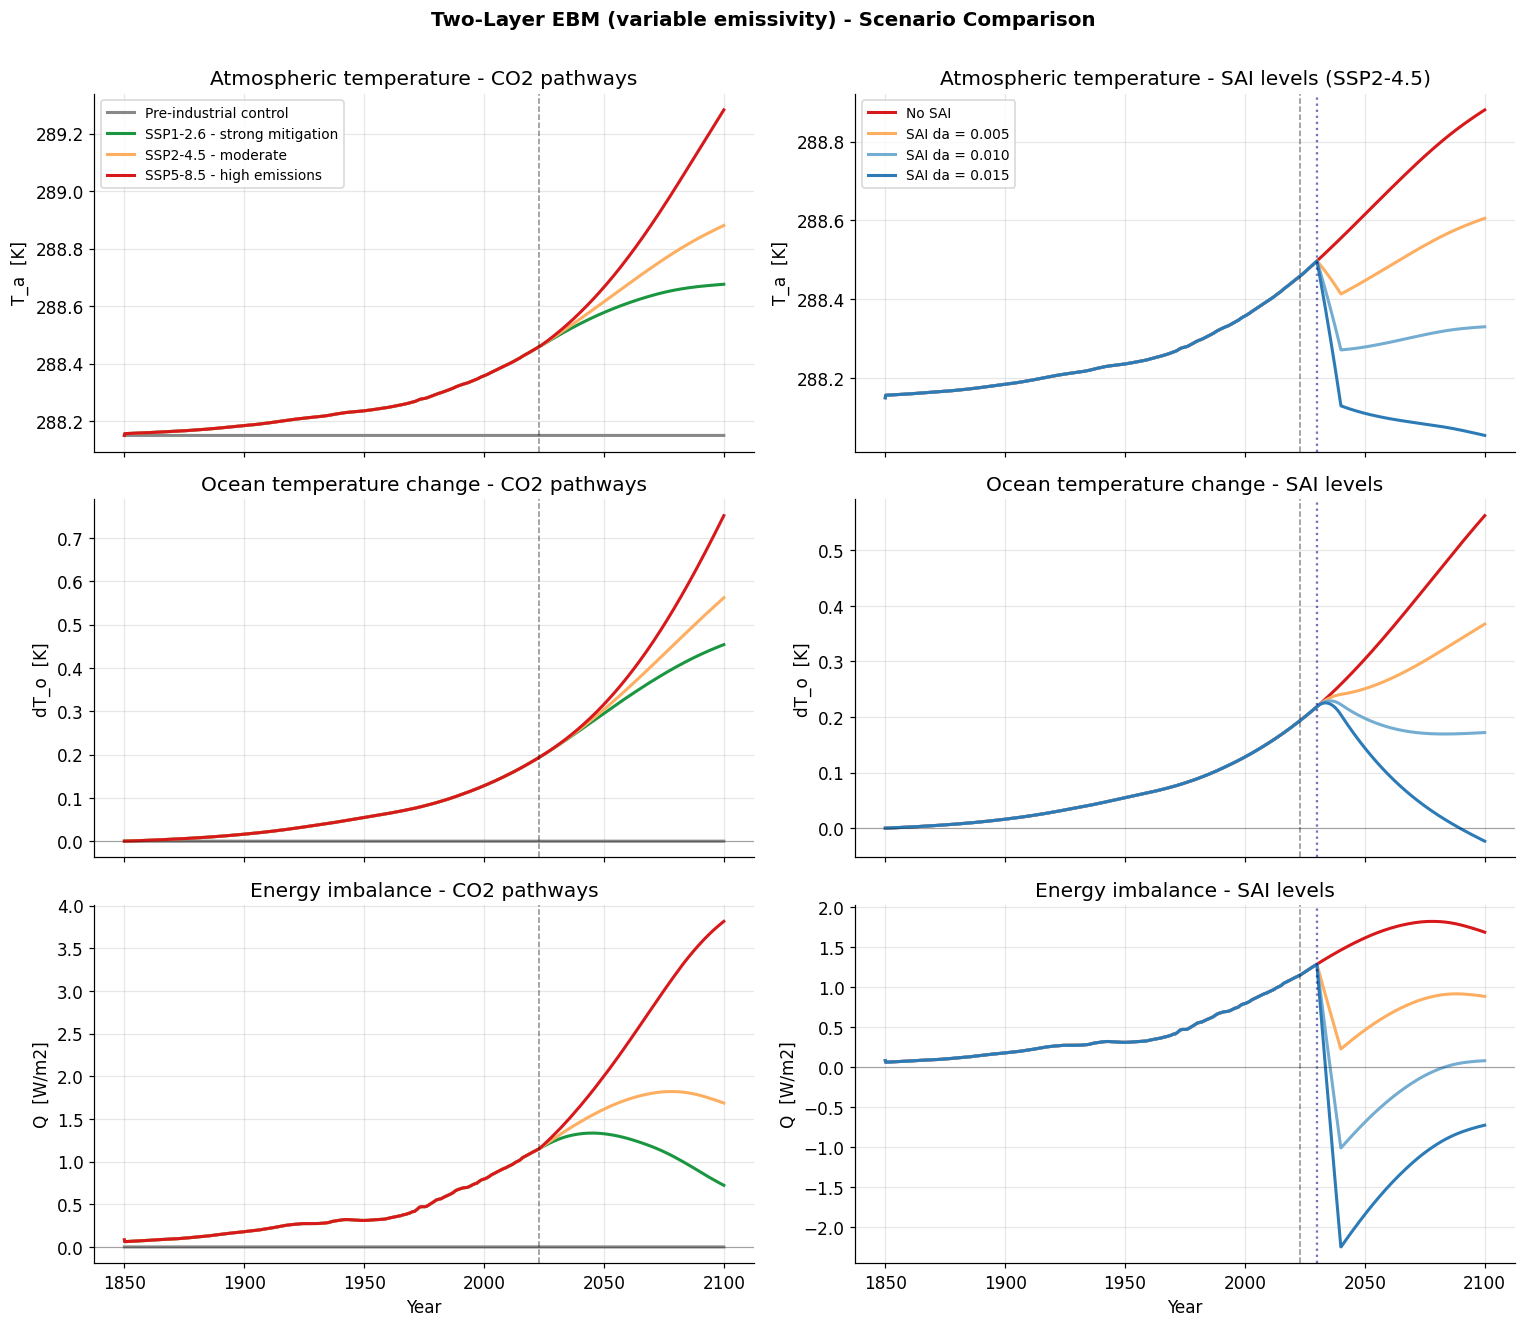

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
fig.suptitle('Two-Layer EBM (variable emissivity) - Scenario Comparison', fontsize=13, fontweight='bold', y=1.003)

# -- CO2 scenarios (no SAI), left column --------------------------------------
co2_cases = [
    ('none',   'Pre-industrial control',  '#888888'),
    ('ssp126', 'SSP1-2.6 - strong mitigation', '#1a9641'),
    ('ssp245', 'SSP2-4.5 - moderate',          '#fdae61'),
    ('ssp585', 'SSP5-8.5 - high emissions',    '#d7191c'),
]
for scen, label, color in co2_cases:
    t, Ta, To, Q = run_ebm(scenario=scen, d_alpha=0.0)
    axes[0, 0].plot(t, Ta,      color=color, lw=2, label=label)
    axes[1, 0].plot(t, To - T0, color=color, lw=2, label=label)
    axes[2, 0].plot(t, Q,       color=color, lw=2, label=label)

# -- SAI levels under SSP2-4.5, right column -----------------------------------
sai_cases = [
    (0.000, 'No SAI',          '#d7191c'),
    (0.005, 'SAI da = 0.005',  '#fdae61'),
    (0.010, 'SAI da = 0.010',  '#74add1'),
    (0.015, 'SAI da = 0.015',  '#2c7bb6'),
]
for da, label, color in sai_cases:
    t, Ta, To, Q = run_ebm(scenario='ssp245', d_alpha=da)
    axes[0, 1].plot(t, Ta,      color=color, lw=2, label=label)
    axes[1, 1].plot(t, To - T0, color=color, lw=2, label=label)
    axes[2, 1].plot(t, Q,       color=color, lw=2, label=label)

# -- Annotations --------------------------------------------------------------
for ax in axes.flat:
    ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.45)
for ax in axes[:, 1]:
    ax.axvline(2030, color='navy', ls=':', lw=1.5, alpha=0.55)
for ax in list(axes[1, :]) + list(axes[2, :]):
    ax.axhline(0, color='k', lw=0.8, alpha=0.3)

axes[0, 0].set(title='Atmospheric temperature - CO2 pathways',         ylabel='T_a  [K]')
axes[0, 1].set(title='Atmospheric temperature - SAI levels (SSP2-4.5)', ylabel='T_a  [K]')
axes[1, 0].set(title='Ocean temperature change - CO2 pathways',        ylabel='dT_o  [K]')
axes[1, 1].set(title='Ocean temperature change - SAI levels',          ylabel='dT_o  [K]')
axes[2, 0].set(title='Energy imbalance - CO2 pathways',                ylabel='Q  [W/m2]', xlabel='Year')
axes[2, 1].set(title='Energy imbalance - SAI levels',                  ylabel='Q  [W/m2]', xlabel='Year')

axes[0, 0].legend(fontsize=9)
axes[0, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Interactive Exploration

Adjust the ocean heat capacity, the atmosphere–ocean coupling $\gamma_{ao}$, the CO₂
pathway, and the SAI deployment to see how each shapes the response in real time.

- **Top-left** — atmospheric temperature, with the SAI cooling offset shaded.
- **Top-right** — ocean temperature change.
- **Middle-left** — net TOA energy imbalance $Q$ and the **ocean heat uptake** $\gamma_{ao}(T_a-T_o)$.
- **Middle-right** — the **CO₂ concentration** $\mathrm{CO_2}(t)$ implied by the scenario
  and the resulting **atmospheric emissivity** $\varepsilon(\mathrm{CO_2})$ — this is the
  new mechanism replacing the linear $a+bT+F(t)$ OLR term.
- **Bottom-left** — energy-balance decomposition $Q = F_{\mathrm{CO_2}} + F_{\mathrm{SAI}} +$
  OLR feedback. Unlike the linear model, the OLR feedback term is the nonlinear Planck
  response $\varepsilon(\mathrm{CO_2})\sigma(T_0^4 - T_a^4)$ rather than $-b(T_a-T_0)$ — but
  the three terms still sum to $Q$ exactly, by construction of $\varepsilon(\mathrm{CO_2})$.
- **Bottom-right** — incoming shortwave $S(1-\alpha(t))$ vs. OLR $\varepsilon(\mathrm{CO_2})\sigma
  T_a^4$ for the SAI run, each point colored by year (viridis). Points above the dashed
  $Q=0$ line indicate a net energy gain.

In [ ]:
def plot_ebm(C_o, gamma_ao, scenario, d_alpha, sai_start, sai_ramp, d_alpha_slope):
    t_b, Ta_b, To_b, Q_b = run_ebm(C_o=C_o, gamma_ao=gamma_ao,
                                    scenario=scenario, d_alpha=0.0)
    t_s, Ta_s, To_s, Q_s = run_ebm(C_o=C_o, gamma_ao=gamma_ao,
                                    scenario=scenario, d_alpha=d_alpha,
                                    sai_start=sai_start, sai_ramp=sai_ramp,
                                    d_alpha_slope=d_alpha_slope)

    fig, axes = plt.subplots(3, 2, figsize=(15, 15), gridspec_kw={'height_ratios': [1, 1, 1.15]})
    fig.subplots_adjust(hspace=0.45, wspace=0.3)

    fig.suptitle(f'Two-Layer EBM (variable emissivity)  |  {scenario.upper()}  |  '
                 f'C_o={C_o:.0f} W.yr/m2/K, gamma_ao={gamma_ao:.2f}',
                 fontsize=12, fontweight='bold')

    # -- Atmospheric temperature -----------------------------------------------
    ax = axes[0, 0]
    ax.plot(t_b, Ta_b, color='#d7191c', lw=2, label='No SAI')
    ax.plot(t_s, Ta_s, color='#2c7bb6', lw=2,
            label=f'SAI da={d_alpha:.3f}, slope={d_alpha_slope:.4f}/yr')
    ax.fill_between(t_s, Ta_b, Ta_s, where=(Ta_s < Ta_b),
                    alpha=0.15, color='#2c7bb6', label='Cooling offset')
    ax.set(title='Atmospheric temperature', ylabel='T_a  [K]', xlabel='Year')

    # -- Ocean temperature change ----------------------------------------------
    ax = axes[0, 1]
    ax.plot(t_b, To_b - T0, color='#d7191c', lw=2, label='No SAI')
    ax.plot(t_s, To_s - T0, color='#2c7bb6', lw=2, label='SAI')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Ocean temperature change', ylabel='dT_o  [K]', xlabel='Year')

    # -- Energy imbalance + ocean heat uptake ----------------------------------
    ax = axes[1, 0]
    ax.plot(t_b, Q_b, color='#d7191c', lw=2, label='Q (TOA), no SAI')
    ax.plot(t_s, Q_s, color='#2c7bb6', lw=2, label='Q (TOA), SAI')
    ax.plot(t_b, gamma_ao * (Ta_b - To_b), color="#fe9408", lw=1.3, ls=':', label='Ocean uptake, no SAI')
    ax.plot(t_s, gamma_ao * (Ta_s - To_s), color="#00fad5", lw=1.3, ls=':', label='Ocean uptake, SAI')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy imbalance & ocean heat uptake', ylabel='W/m2', xlabel='Year')

    # -- CO2 concentration & atmospheric emissivity -----------------------------
    ax = axes[1, 1]
    CO2_s = np.array([co2_ppm(ti, scenario=scenario) for ti in t_s])
    eps_s = emissivity(CO2_s)
    ln1 = ax.plot(t_s, CO2_s, color='#8c510a', lw=2, label='CO2  [ppm]')
    ax.set(title='CO2 concentration & atmospheric emissivity', ylabel='CO2  [ppm]', xlabel='Year')
    ax2 = ax.twinx()
    ln2 = ax2.plot(t_s, eps_s, color='#01665e', lw=2, ls='--', label='eps(CO2)')
    ax2.set_ylabel('emissivity  eps  [-]')
    ax2.grid(False)
    lns = ln1 + ln2
    ax.legend(lns, [l.get_label() for l in lns], fontsize=8, loc='upper left')

    # -- Energy-balance decomposition (SAI run) ---------------------------------
    # Exact identity: Q = F_co2 + F_sai + OLR_fb, where the Planck feedback term
    # eps(CO2)*sigma*(T0^4 - Ta^4) replaces the linear model's -b*(Ta-T0).
    ax = axes[2, 0]
    F_co2  = np.array([co2_forcing(ti, scenario=scenario) for ti in t_s])
    F_sai  = np.array([-S * sai_delta_alpha(ti, d_alpha=d_alpha, start_year=sai_start,
                                             ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope)
                        for ti in t_s])
    OLR_fb = eps_s * SIGMA * (T0**4 - Ta_s**4)
    Q_dec  = F_co2 + F_sai + OLR_fb
    ax.fill_between(t_s, F_co2,  alpha=0.35, color='#d7191c', label='CO2 forcing  F(t)')
    ax.fill_between(t_s, F_sai,  alpha=0.35, color='#2c7bb6', label='SAI forcing  -S*da(t)')
    ax.fill_between(t_s, OLR_fb, alpha=0.35, color='#fdae61', label='OLR feedback  eps*sigma*(T0^4-Ta^4)')
    ax.plot(t_s, Q_dec, 'k-', lw=1.6, label='Q  (sum)')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy balance decomposition (SAI run)', ylabel='W/m2', xlabel='Year')

    for ax in axes.flat[:-1]:
        ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.4)
        if d_alpha > 0:
            ax.axvline(sai_start,            color='navy',      ls=':', lw=1.5, alpha=0.5)
            ax.axvline(sai_start + sai_ramp, color='steelblue', ls=':', lw=1.0, alpha=0.5)
    for ax in [axes[0, 0], axes[0, 1], axes[1, 0], axes[2, 0]]:
        ax.legend(fontsize=8)

    # -- Incoming shortwave vs. OLR, colored by year (SAI run) -----------------
    ax5 = axes[2, 1]
    alpha_s = alpha0 + np.array([sai_delta_alpha(ti, d_alpha=d_alpha, start_year=sai_start,
                                                  ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope)
                                  for ti in t_s])
    S_in  = S * (1 - alpha_s)
    OLR_s = eps_s * SIGMA * Ta_s**4

    lims = [min(OLR_s.min(), S_in.min()), max(OLR_s.max(), S_in.max())]
    ax5.plot(lims, lims, color='k', lw=0.8, ls='--', alpha=0.4, label='S(1-a) = OLR  (Q = 0)')
    sc = ax5.scatter(OLR_s, S_in, c=t_s, cmap='viridis', s=14, edgecolor='none')
    fig.colorbar(sc, ax=ax5, label='Year', pad=0.01)
    ax5.set(title='Incoming shortwave vs. OLR (SAI run)',
            xlabel='OLR = eps(CO2)*sigma*T_a^4  [W/m2]', ylabel='S(1 - alpha(t))  [W/m2]')
    ax5.legend(fontsize=8, loc='upper left')

    plt.tight_layout()
    plt.show()


interact(
    plot_ebm,
    C_o          = FloatSlider(value=C_OCEAN,  min=50.0, max=700.0, step=10.0,   description='C_o [W.yr/m2/K]',        style={'description_width': 'initial'}),
    gamma_ao     = FloatSlider(value=GAMMA_AO, min=0.5,  max=20.0,  step=0.5,    description='gamma_ao [W/m2/K]',      style={'description_width': 'initial'}, readout_format='.2f'),
    scenario     = Dropdown(options=['none', 'ssp126', 'ssp245', 'ssp585'], value='ssp245', description='CO2 scenario'),
    d_alpha      = FloatSlider(value=0.0,  min=0.0,  max=0.015,  step=0.0005,  description='SAI da',                 style={'description_width': 'initial'}, readout_format='.4f'),
    sai_start    = IntSlider(  value=2030, min=2025, max=2080,    step=5,      description='SAI start year',         style={'description_width': 'initial'}),
    sai_ramp     = IntSlider(  value=10,   min=1,    max=30,      step=1,      description='Ramp-up years',          style={'description_width': 'initial'}),
    d_alpha_slope= FloatSlider(value=0.0,  min=0.0,  max=0.00025,  step=0.000005, description='Post-ramp slope (da/yr)', style={'description_width': 'initial'}, readout_format='.5f'),
);

interactive(children=(FloatSlider(value=340.456103241753, description='C_o [W.yr/m2/K]', max=700.0, min=50.0, …

In [23]:
### Controller for constant atmospheric temperature
#
# ARISE-1.5-style closed-loop SAI feedback controller (simplified analog --
# not the actual ensemble PI-controller used in ARISE, but the same two-phase
# structure):
#
#   t < 2035          : no SAI, baseline warming under the CO2 scenario
#   2035 <= t < 2045  : ramp-in -- T_target is frozen at whatever T_a is when
#                       the ramp begins (2035), and each year the controller
#                       solves for the d_alpha that would hold Ta AT T_target
#                       given the current ocean state, then applies only a
#                       linearly increasing fraction of it (0 -> 1 over the
#                       decade)
#   t >= 2045         : full control -- each year the controller re-solves
#                       for the d_alpha that holds Ta at the same fixed
#                       T_target and applies it in full
#
# The "solve" is closed-form. Because the atmospheric heat capacity C_a is
# tiny (~0.03 yr response time) compared to the annual control step, Ta
# relaxes to its instantaneous radiative equilibrium well within each year --
# so choosing d_alpha to make T_target *itself* that equilibrium (rather than
# solving relative to whatever Ta has drifted to) is what actually pins Ta,
# instead of merely freezing its rate of change from a moving baseline.
# Setting Ta = T_target in
#   C_a dTa/dt = S(1 - alpha0 - d_alpha) - eps(CO2(t))*sigma*Ta^4 - gamma_ao*(Ta-To)
# and solving dTa/dt = 0 for d_alpha gives
#   d_alpha = (1 - alpha0) - [eps(CO2(t))*sigma*T_target^4 + gamma_ao*(T_target - To)] / S

CTRL_START = 2035   # year SAI ramp-in begins
CTRL_RAMP  = 10      # ramp-in duration [yr]; full control from CTRL_START+CTRL_RAMP


def controller_d_alpha_step(T_target, To, t_year, scenario, gamma_ao):
    """SAI albedo offset that holds Ta at the fixed T_target, given the current ocean state."""
    eps = emissivity(co2_ppm(t_year, scenario=scenario))
    d_alpha = (1 - alpha0) - (eps * SIGMA * T_target**4 + gamma_ao * (T_target - To)) / S
    return max(d_alpha, 0.0)   # SAI only adds reflective aerosol -- no negative injection


def _layer_derivs_fixed_alpha(t, y, C_a, C_o, gamma_ao, d_alpha, scenario):
    """Two-layer RHS with a single, already-solved albedo offset held fixed."""
    Ta, To = y
    eps  = emissivity(co2_ppm(t, scenario=scenario))
    R    = S * (1 - (alpha0 + d_alpha)) - eps * SIGMA * Ta**4
    f_ao = gamma_ao * (Ta - To)
    return [(R - f_ao) / C_a, f_ao / C_o]


def run_controller_ebm(C_o=C_OCEAN, gamma_ao=GAMMA_AO, scenario='ssp245',
                        t_span=(1850, 2100), pts_per_year=8):
    """
    Integrate the two-layer EBM one calendar year at a time, re-solving the
    controller's d_alpha at the start of each year (see module docstring
    above) and holding it fixed while that year is integrated.

    Returns
    -------
    t, Ta, To, Q, d_alpha : all on the same fine (sub-year) grid.
    T_target               : the frozen atmospheric-temperature target [K].
    """
    C_a = C_ATMOS
    t0, t_end = t_span
    years = np.arange(t0, t_end)

    t_chunks, Ta_chunks, To_chunks, da_chunks = [], [], [], []
    y = [T0, T0]
    T_target = None

    for yr in years:
        if yr < CTRL_START:
            d_alpha = 0.0
        else:
            if T_target is None:
                T_target = y[0]   # freeze the target at the state when the ramp begins
            d_alpha_full = controller_d_alpha_step(T_target, y[1], yr, scenario, gamma_ao)
            ramp_frac = min(1.0, (yr - CTRL_START + 1) / CTRL_RAMP)
            d_alpha = ramp_frac * d_alpha_full

        t_eval = np.linspace(yr, yr + 1, pts_per_year, endpoint=False)
        sol = solve_ivp(lambda t, yy: _layer_derivs_fixed_alpha(t, yy, C_a, C_o, gamma_ao,
                                                                  d_alpha, scenario),
                        (yr, yr + 1), y, t_eval=t_eval,
                        method='BDF', rtol=1e-8, atol=1e-10, dense_output=True)

        t_chunks.append(sol.t)
        Ta_chunks.append(sol.y[0])
        To_chunks.append(sol.y[1])
        da_chunks.append(np.full_like(sol.t, d_alpha))
        y = sol.sol(yr + 1)   # true state at the year boundary (t_eval excludes
                               # it via endpoint=False, so sol.y[:, -1] is the
                               # state at yr+0.875 -- using that as next year's
                               # IC silently skips the last 1/pts_per_year of
                               # each year and re-injects a stale state)

    t  = np.concatenate(t_chunks)
    Ta = np.concatenate(Ta_chunks)
    To = np.concatenate(To_chunks)
    d_alpha_t = np.concatenate(da_chunks)

    eps_t = emissivity(np.array([co2_ppm(ti, scenario=scenario) for ti in t]))
    Q = S * (1 - (alpha0 + d_alpha_t)) - eps_t * SIGMA * Ta**4
    return t, Ta, To, Q, d_alpha_t, T_target


def plot_controller_ebm(C_o, gamma_ao, scenario):
    t_c, Ta_c, To_c, Q_c, da_c, T_target = run_controller_ebm(C_o=C_o, gamma_ao=gamma_ao, scenario=scenario)
    t_b, Ta_b, To_b, Q_b               = run_ebm(C_o=C_o, gamma_ao=gamma_ao, scenario=scenario, d_alpha=0.0)

    fig, axes = plt.subplots(3, 2, figsize=(15, 15), gridspec_kw={'height_ratios': [1, 1, 1.15]})
    fig.subplots_adjust(hspace=0.45, wspace=0.3)

    fig.suptitle(f'Two-Layer EBM  |  Constant-T_a SAI Controller  |  {scenario.upper()}  |  '
                 f'C_o={C_o:.0f} W.yr/m2/K, gamma_ao={gamma_ao:.2f}',
                 fontsize=12, fontweight='bold')

    # -- Atmospheric temperature -----------------------------------------------
    ax = axes[0, 0]
    ax.plot(t_b, Ta_b, color='#d7191c', lw=2, label='No SAI (baseline)')
    ax.plot(t_c, Ta_c, color='#2c7bb6', lw=2, label='Controller (constant T_a)')
    if T_target is not None:
        ax.axhline(T_target, color='#2c7bb6', lw=1, ls=':', alpha=0.6, label=f'T_target = {T_target:.2f} K')
    ax.set(title='Atmospheric temperature', ylabel='T_a  [K]', xlabel='Year')

    # -- Ocean temperature change ----------------------------------------------
    ax = axes[0, 1]
    ax.plot(t_b, To_b - T0, color='#d7191c', lw=2, label='No SAI (baseline)')
    ax.plot(t_c, To_c - T0, color='#2c7bb6', lw=2, label='Controller')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Ocean temperature change', ylabel='dT_o  [K]', xlabel='Year')

    # -- Energy imbalance + ocean heat uptake ----------------------------------
    ax = axes[1, 0]
    ax.plot(t_b, Q_b, color='#d7191c', lw=2, label='Q (TOA), no SAI')
    ax.plot(t_c, Q_c, color='#2c7bb6', lw=2, label='Q (TOA), controller')
    ax.plot(t_b, gamma_ao * (Ta_b - To_b), color="#fe9408", lw=1.3, ls=':', label='Ocean uptake, no SAI')
    ax.plot(t_c, gamma_ao * (Ta_c - To_c), color="#00fad5", lw=1.3, ls=':', label='Ocean uptake, controller')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy imbalance & ocean heat uptake', ylabel='W/m2', xlabel='Year')

    # -- CO2 concentration & atmospheric emissivity -----------------------------
    ax = axes[1, 1]
    CO2_c = np.array([co2_ppm(ti, scenario=scenario) for ti in t_c])
    eps_c = emissivity(CO2_c)
    ln1 = ax.plot(t_c, CO2_c, color='#8c510a', lw=2, label='CO2  [ppm]')
    ax.set(title='CO2 concentration & atmospheric emissivity', ylabel='CO2  [ppm]', xlabel='Year')
    ax2 = ax.twinx()
    ln2 = ax2.plot(t_c, eps_c, color='#01665e', lw=2, ls='--', label='eps(CO2)')
    ax2.set_ylabel('emissivity  eps  [-]')
    ax2.grid(False)
    lns = ln1 + ln2
    ax.legend(lns, [l.get_label() for l in lns], fontsize=8, loc='upper left')

    # -- Controller SAI injection ------------------------------------------------
    ax = axes[2, 0]
    ax.plot(t_c, da_c, color='#762a83', lw=2, label='SAI d_alpha (solved)')
    ax.set(title='Controller SAI injection', ylabel='d_alpha  [-]', xlabel='Year')
    ax.legend(fontsize=8)

    for ax in axes.flat[:-1]:
        ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.4)
        ax.axvline(CTRL_START,            color='navy',      ls=':', lw=1.5, alpha=0.5)
        ax.axvline(CTRL_START + CTRL_RAMP, color='steelblue', ls=':', lw=1.0, alpha=0.5)
    for ax in [axes[0, 0], axes[0, 1], axes[1, 0]]:
        ax.legend(fontsize=8)

    # -- Incoming shortwave vs. OLR, colored by year (controller run) ----------
    # Annual means -- one point per calendar year, rather than one point per
    # sub-year integration step, since the sub-year spread within a year is a
    # real but uninteresting transient (see the per-year re-solve above) that
    # otherwise dominates the plot.
    ax5 = axes[2, 1]
    S_in  = S * (1 - (alpha0 + da_c))
    OLR_c = eps_c * SIGMA * Ta_c**4

    year_labels, year_idx = np.unique(np.floor(t_c).astype(int), return_inverse=True)
    counts       = np.bincount(year_idx)
    S_in_annual  = np.bincount(year_idx, weights=S_in)  / counts
    OLR_annual   = np.bincount(year_idx, weights=OLR_c) / counts

    lims = [min(OLR_annual.min(), S_in_annual.min()), max(OLR_annual.max(), S_in_annual.max())]
    ax5.plot(lims, lims, color='k', lw=0.8, ls='--', alpha=0.4, label='S(1-a) = OLR  (Q = 0)')
    sc = ax5.scatter(OLR_annual, S_in_annual, c=year_labels, cmap='viridis', s=14, edgecolor='none')
    fig.colorbar(sc, ax=ax5, label='Year', pad=0.01)
    ax5.set(title='Incoming shortwave vs. OLR (controller run, annual means)',
            xlabel='OLR = eps(CO2)*sigma*T_a^4  [W/m2]', ylabel='S(1 - alpha(t))  [W/m2]')
    ax5.legend(fontsize=8, loc='upper left')

    plt.tight_layout()
    plt.show()


interact(
    plot_controller_ebm,
    C_o      = FloatSlider(value=C_OCEAN,  min=50.0, max=700.0, step=10.0, description='C_o [W.yr/m2/K]',   style={'description_width': 'initial'}),
    gamma_ao = FloatSlider(value=GAMMA_AO, min=0.5,  max=20.0,  step=0.5,  description='gamma_ao [W/m2/K]', style={'description_width': 'initial'}, readout_format='.2f'),
    scenario = Dropdown(options=['none', 'ssp126', 'ssp245', 'ssp585'], value='ssp245', description='CO2 scenario'),
);

interactive(children=(FloatSlider(value=340.456103241753, description='C_o [W.yr/m2/K]', max=700.0, min=50.0, …

## Ocean Coupling Sensitivity

The key tunable parameter in this model is $\gamma_{ao}$, which controls how quickly
heat transfers from the atmosphere to the ocean.  A larger $\gamma_{ao}$ couples
the layers more tightly, giving a faster ocean response and a smaller persistent
energy imbalance $Q$.  Below: both layers' responses for five values of $\gamma_{ao}$
under SSP2-4.5 with a moderate SAI deployment ($\Delta\alpha = 0.010$).

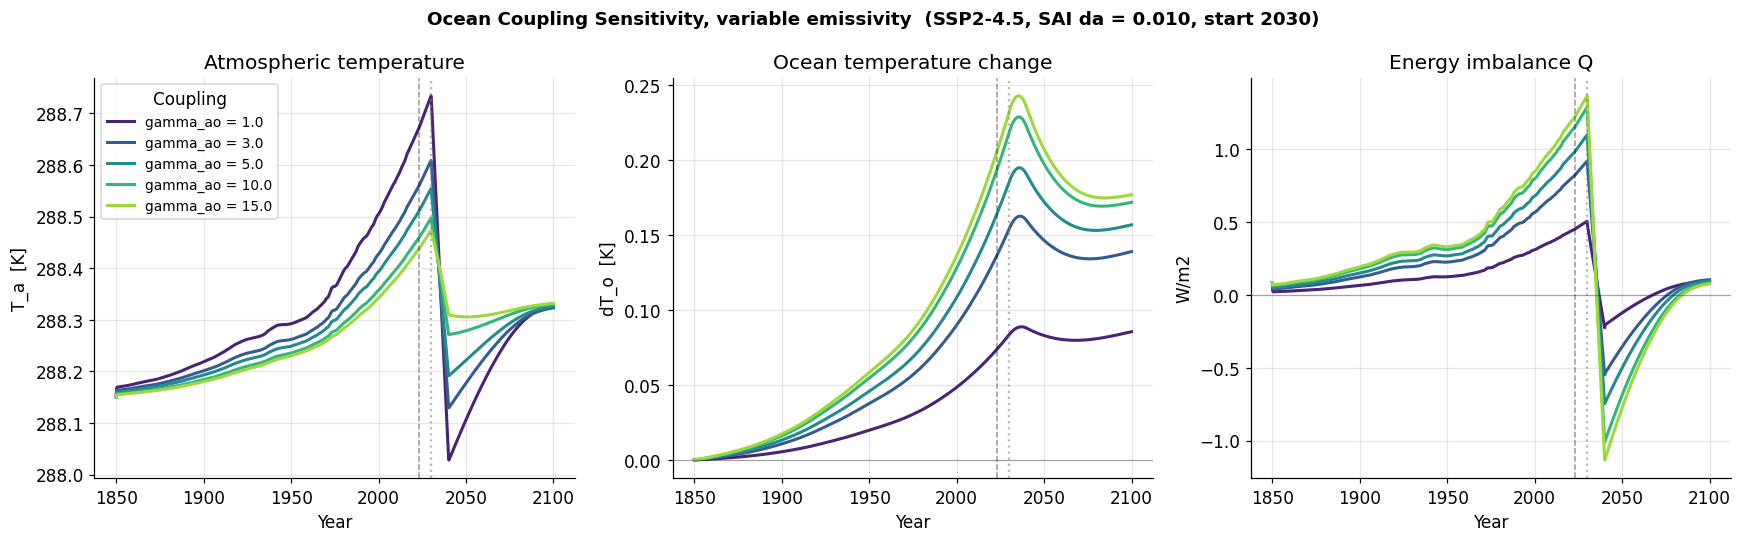

In [22]:
gamma_values = [1.0, 3.0, 5.0, 10.0, 15.0]
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(gamma_values)))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Ocean Coupling Sensitivity, variable emissivity  (SSP2-4.5, SAI da = 0.010, start 2030)',
             fontsize=12, fontweight='bold')

for g, color in zip(gamma_values, colors):
    t, Ta, To, Q = run_ebm(scenario='ssp245', d_alpha=0.010, gamma_ao=g)
    axes[0].plot(t, Ta,      color=color, lw=2, label=f'gamma_ao = {g}')
    axes[1].plot(t, To - T0, color=color, lw=2)
    axes[2].plot(t, Q,       color=color, lw=2)

for ax in axes:
    ax.axvline(2023, color='k',    ls='--', lw=1,   alpha=0.4)
    ax.axvline(2030, color='gray', ls=':',  lw=1.5, alpha=0.55)
axes[1].axhline(0, color='k', lw=0.8, alpha=0.3)
axes[2].axhline(0, color='k', lw=0.8, alpha=0.3)

axes[0].set(title='Atmospheric temperature',     ylabel='T_a  [K]',  xlabel='Year')
axes[1].set(title='Ocean temperature change',    ylabel='dT_o  [K]', xlabel='Year')
axes[2].set(title='Energy imbalance Q',          ylabel='W/m2',      xlabel='Year')

axes[0].legend(title='Coupling', fontsize=9)

plt.tight_layout()
plt.show()

### Features to add or verify performance
-fix CO2 ramp from 1850-2023 and for RCP conditions
-fix T_a to match SSP2-4.5 (may need to add a second ocean layer)
-add ARISE 1.5 solver
-is methane’s impact negligible? Are the changes to CO2 not sufficient to represent emissivity changes?
